## Generación de Datos Sintéticos y Regresión Lineal

# **Actividad 1 (Regresión lineal simple)**
### Rafael Santamaria Heredia | A01646667

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Semilla
np.random.seed(42) # Establecer la semilla
n_samples = 100
x = np.random.rand(n_samples) * 10 # Generar valores de x entre 0 y 10

# Generate error term
error = np.random.randn(n_samples) * 2 # Gaussian noise with standard deviation of 2

# 2. Generar y = 2x + 3 + error
y = 2 * x + 3 + error

### Cálculo de Varianza

In [3]:
# 3. Calcular la varianza
variance_x = np.var(x)
variance_y = np.var(y)

print(f"Varianza de x: {variance_x:.2f}")
print(f"Varianza de y: {variance_y:.2f}")

Varianza de x: 8.76
Varianza de y: 35.12


### Cálculo de Beta0 y Beta1 (Regresión Lineal Simple)

In [4]:
# 4. Calcular beta0 (intercept) y beta1 (slope)
# Using las formulas para regresion lineal simple

# Calcular medias
mean_x = np.mean(x)
mean_y = np.mean(y)

# Calcular beta1 (slope)
# beta1 = sum((x_i - mean_x) * (y_i - mean_y)) / sum((x_i - mean_x)^2)
numerator = np.sum((x - mean_x) * (y - mean_y))
denominator = np.sum((x - mean_x)**2)
beta1 = numerator / denominator

# Calcular beta0 (intercept)
# beta0 = mean_y - beta1 * mean_x
beta0 = mean_y - beta1 * mean_x

print(f"Beta0 (Intercepto): {beta0:.2f}")
print(f"Beta1 (Pendiente): {beta1:.2f}")

Beta0 (Intercepto): 3.43
Beta1 (Pendiente): 1.91


### Cálculo de R-cuadrado (R²) y Error Cuadrático Medio (MSE)

In [5]:
import numpy as np

# 5. Calcular R-squared (R^2) and Mean Squared Error (MSE)

# Predicciones de valores de Y
y_pred = beta0 + beta1 * x

# Calcular Total Sum of Squares (SST)
sst = np.sum((y - mean_y)**2)

# Calcular Residual Sum of Squares (SSR)
ssr = np.sum((y - y_pred)**2)

# Calcular R-squared
r_squared = 1 - (ssr / sst)

# Calcular Mean Squared Error (MSE)
mse = np.mean((y - y_pred)**2)

# Calcular Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calcular Mean Absolute Error (MAE)
mae = np.mean(np.abs(y - y_pred))

# Calcular Mean Absolute Percentage Error (MAPE)
# Evitar división por cero, reemplazar por NaN si y es 0
mape = np.mean(np.abs((y - y_pred) / y[y != 0])) * 100 if np.any(y != 0) else np.nan

# Calcular Sigma Cuadrada (Varianza de los residuos)
# Para regresión lineal simple, los grados de libertad son n - 2
if n_samples > 2:
    sigma_cuadrada = ssr / (n_samples - 2)
    sigma_estimado = np.sqrt(sigma_cuadrada)
else:
    sigma_cuadrada = np.nan
    sigma_estimado = np.nan

print(f"R-cuadrado (R^2): {r_squared:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape:.2f}%")
print(f"Sigma Cuadrada (Varianza de los residuos): {sigma_cuadrada:.2f}")
print(f"Sigma Estimado (Desviación estándar de los residuos): {sigma_estimado:.2f}")


R-cuadrado (R^2): 0.91
Error Cuadrático Medio (MSE): 3.23
Raíz del Error Cuadrático Medio (RMSE): 1.80
Error Absoluto Medio (MAE): 1.40
Error Porcentual Absoluto Medio (MAPE): 15.86%
Sigma Cuadrada (Varianza de los residuos): 3.29
Sigma Estimado (Desviación estándar de los residuos): 1.81


### Visualización de los Datos y la Línea de Regresión

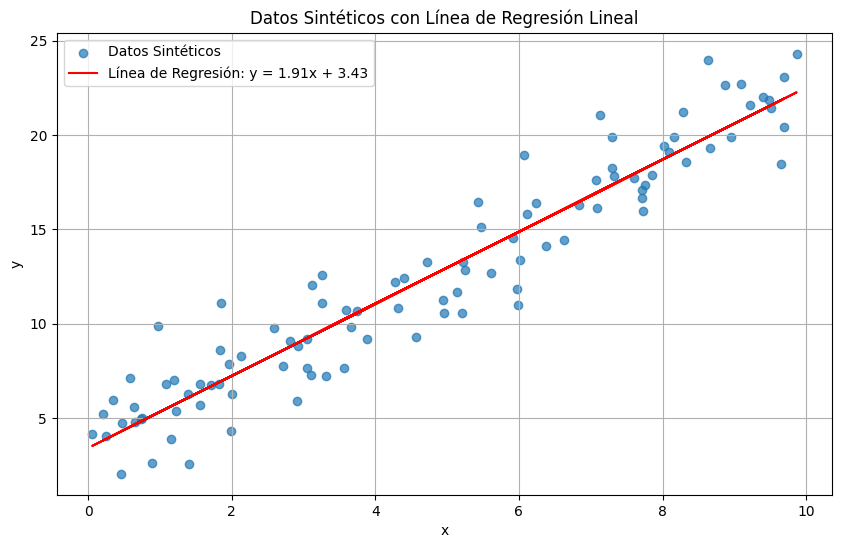

In [6]:
# 6. Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Datos Sintéticos', alpha=0.7)
plt.plot(x, y_pred, color='red', label=f'Línea de Regresión: y = {beta1:.2f}x + {beta0:.2f}')
plt.title('Datos Sintéticos con Línea de Regresión Lineal')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### Visualización de los Residuos

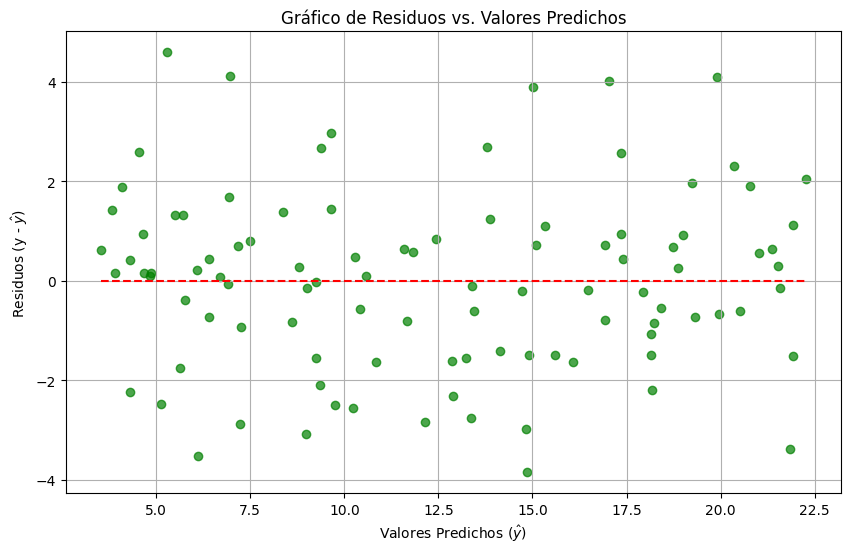

In [7]:
residuals = y - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7, color='green')
plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), colors='red', linestyles='--')
plt.title('Gráfico de Residuos vs. Valores Predichos')
plt.xlabel(r'Valores Predichos ($\hat{y}$)')
plt.ylabel(r'Residuos (y - $\hat{y}$)')
plt.grid(True)
plt.show()

### Cálculo de Betas usando el Método de Matrices (Ecuaciones Normales)

In [8]:
import numpy as np

# 1. Construir la Matriz de Diseño X
# Para una regresión lineal simple, X tendrá una columna de unos (para el intercepto)
# y una columna con los valores de la variable independiente x.
# np.vstack apila arrays verticalmente, y .T transpone para obtener la forma correcta.
X = np.vstack((np.ones(n_samples), x)).T

# 2. Calcular los coeficientes Beta usando la fórmula de las ecuaciones normales:
# beta_vector = (X^T * X)^-1 * X^T * y

# X.T @ X es la multiplicación matricial de X transpuesta por X
X_transpose_X = X.T @ X

# np.linalg.inv calcula la inversa de una matriz
inverse_X_transpose_X = np.linalg.inv(X_transpose_X)

# X.T @ y es la multiplicación matricial de X transpuesta por y
X_transpose_y = X.T @ y

# Finalmente, el vector de coeficientes beta
beta_vector = inverse_X_transpose_X @ X_transpose_y

beta0_matrix = beta_vector[0]
beta1_matrix = beta_vector[1]

print(f"Beta0 (Intercepto) usando el método de matrices: {beta0_matrix:.2f}")
print(f"Beta1 (Pendiente) usando el método de matrices: {beta1_matrix:.2f}")

print(f"\nComparación con los valores calculados previamente:")
print(f"Beta0 (Intercepto) previo: {beta0:.2f}")
print(f"Beta1 (Pendiente) previo: {beta1:.2f}")

Beta0 (Intercepto) usando el método de matrices: 3.43
Beta1 (Pendiente) usando el método de matrices: 1.91

Comparación con los valores calculados previamente:
Beta0 (Intercepto) previo: 3.43
Beta1 (Pendiente) previo: 1.91


In [19]:
from google.colab import drive, files
import os

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Pide la ruta completa del notebook (o puedes pegarla directamente en la variable)
ruta_ipynb = input("Pega aquí la ruta del archivo .ipynb en tu Drive: ").strip().replace("'", "").replace('"', '')

# Validar y convertir
if os.path.exists(ruta_ipynb):
    # Convertir a HTML
    os.system(f"jupyter nbconvert --to html '{ruta_ipynb}'")

    # Ruta del archivo HTML generado (se crea en la misma carpeta del ipynb)
    ruta_html = os.path.splitext(ruta_ipynb)[0] + ".html"

    # Descargar a tu computadora
    files.download(ruta_html)
    print("✅ Descarga iniciada con éxito.")
else:
    print(f"❌ No se encontró el archivo en: {ruta_ipynb}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pega aquí la ruta del archivo .ipynb en tu Drive: /content/drive/MyDrive/Aplicación de métodos multivariados en ciencia de datos/ACTIVIDAD 1.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga iniciada con éxito.
